## Short-Term Load Forecasting Model

**Team 08** | BU DS591 | Spring 2026

---

In this notebook, we be train and evaluate several forecasting models. We will be using the ISO-NE and EIA data from our pipeline to be accomplishing this. The targets are `target_load_mw` (load 5 minutes ahead) and  detecting grid stress events. We define a stress event as where load deviates significantly from the recent rolling baseline.

#### Dataset
| Field | Value |
|---|---|
| Source | ISO-NE Real-Time 5-Minute System Load (Gold layer, ADLS) |
| ADLS path | `gold/iso-ne-stream/demand_features.parquet` |
| Rows | 10,252 intervals (5-min resolution) |
| Coverage | July 2025 – May 2026 |
| Features | 18 engineered columns |
| Target | `target_load_mw` next interval's total system load (MW) |

#### Project Predictions
| # | Prediction | Evaluated Via |
|---|---|---|
| 1 | Seasonal demand patterns (summer vs winter) | EIA batch Gold table summer/winter ratio by state |
| 2 | AI/industrial growth impact | EIA batch Gold table industrial CAGR 2022–2025 |
| 3 | Weekly operational patterns | Streaming `is_weekend` + EIA monthly cycle proxy |
| 4 | Forecast accuracy and grid stress detection | Model MAPE vs ISO-NE benchmark + stress F1 |

In [ ]:
# imports and ADLS data loading
import io, os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from azure.storage.filedatalake import DataLakeServiceClient

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import TimeSeriesSplit

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print('XGBoost available')
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed -- run: pip install xgboost')

load_dotenv()

GOLD_CONTAINER = 'gold'
GOLD_DIR       = 'iso-ne-stream/demand_features.parquet'

conn_str = os.environ.get('ADLS_CONNECTION_STRING')
if not conn_str:
    sys.exit('ERROR: ADLS_CONNECTION_STRING not set in .env')

client = DataLakeServiceClient.from_connection_string(conn_str)
fs     = client.get_file_system_client(GOLD_CONTAINER)

def _is_data_file(item):
    name = item['name']
    size = item.get('content_length', 0) or 0
    return size > 0 and (name.endswith('.parquet') or 'snappy' in name)

all_items  = list(fs.get_paths(GOLD_DIR, recursive=False))
part_files = sorted(item['name'] for item in all_items if _is_data_file(item))

if not part_files:
    print(f'No parquet part files found under gold/{GOLD_DIR}.')
    print('Contents of that path:')
    for item in all_items:
        print(f'  {item["name"]}  ({item.get("content_length", "?")} bytes)')
    raise FileNotFoundError(f'gold/{GOLD_DIR} contains no readable parquet data')

print(f'Found {len(part_files)} part file(s) in {GOLD_DIR}:')
frames = []
for path in part_files:
    raw = fs.get_file_client(path).download_file().readall()
    frames.append(pd.read_parquet(io.BytesIO(raw)))
    print(f'  {path}  ({len(raw):,} bytes)')

df_raw = pd.concat(frames, ignore_index=True) if len(frames) > 1 else frames[0]
df_raw['event_time'] = pd.to_datetime(df_raw['event_time'], utc=True)

n_rows = len(df_raw)
n_cols = len(df_raw.columns)
print(f'\nLoaded {n_rows} rows, {n_cols} columns from Gold layer')
print(f'Columns: {list(df_raw.columns)}')

XGBoost available
Found 1 part file(s) in iso-ne-stream/demand_features.parquet:
  iso-ne-stream/demand_features.parquet/part-00000-dd8fcd74-5ae7-4e20-86fe-0b0612f92fe8-c000.snappy.parquet  (991,273 bytes)

Loaded 10252 rows, 36 columns from Gold layer
Columns: ['event_time', 'target_load_mw', 'total_load_mw', 'native_load_mw', 'asset_related_load_mw', 'total_load_w_solar_mw', 'native_load_w_solar_mw', 'rolling_3_avg_mw', 'rolling_12_avg_mw', 'demand_change_pct', 'stress_flag', 'ingestion_lag_seconds', 'hour_of_day', 'minute_of_hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'is_weekday', 'is_morning_peak', 'is_evening_peak', 'is_peak_hour', 'is_overnight', 'season_int', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_6', 'load_lag_12', 'load_delta_mw']


## Data Overview

The Gold-layer Parquet is a pre-engineered feature matrix produced by `transformation/silver_to_gold.py` from the ISO-NE 5-minute demand feed.

| Column Group | Columns | Notes |
|---|---|---|
| Target | `target_load_mw` | Next interval's load excluded from features |
| Raw signals | `total_load_mw`, `asset_related_load_mw` | Current system state |
| Lag features | `load_lag_1/2/3/6/12` | 5-min steps back; nulled across sequence gaps |
| Rolling averages | `rolling_3_avg_mw`, `rolling_12_avg_mw` | Backward-looking only|
| Rate of change | `load_delta_mw` | Current ramp direction |
| Cyclical time | `hour_sin/cos`, `month_sin/cos`, `dow_sin/cos` | Continuous circular encoding of periodic scales |
| Calendar flags | `is_weekend`, `is_peak_hour`, `season_int` | Structural demand differences |
| Stress label | `stress_flag` | True when load deviates >5% from `rolling_12_avg_mw` |

In [ ]:
# data validation

# derived columns for downstream
df_raw['season'] = df_raw['season_int'].map({0:'winter', 1:'spring', 2:'summer', 3:'fall'})
df_raw['is_overnight'] = df_raw['hour_of_day'].between(0, 5).astype(int)
df_raw['stress_flag'] = df_raw['stress_flag'].astype(bool)

dt_min   = df_raw['event_time'].min().date()
dt_max   = df_raw['event_time'].max().date()
load_min = df_raw['total_load_mw'].min()
load_max = df_raw['total_load_mw'].max()
load_avg = df_raw['total_load_mw'].mean()
n_stress = int(df_raw['stress_flag'].sum())
pct      = n_stress / len(df_raw) * 100

print('=== Dataset Summary ===')
print(f'Shape:        {df_raw.shape}')
print(f'Date range:   {dt_min} to {dt_max}')
print(f'Load range:   {load_min:.0f} to {load_max:.0f} MW')
print(f'Avg load:     {load_avg:.0f} MW')
print(f'Stress flags: {n_stress} ({pct:.1f}% of all intervals)')

key_cols = ['target_load_mw', 'load_lag_1', 'load_lag_12',
            'rolling_3_avg_mw', 'rolling_12_avg_mw', 'stress_flag']
print('\nNull counts in key columns:')
null_counts = df_raw[key_cols].isnull().sum().to_frame('nulls')
print(null_counts)

print('\nSeason distribution:')
print(df_raw['season'].value_counts().to_frame('count'))

df_raw[['total_load_mw', 'target_load_mw', 'load_lag_1', 'rolling_12_avg_mw']].describe().round(1)

=== Dataset Summary ===
Shape:        (10252, 37)
Date range:   2025-07-18 to 2026-05-03
Load range:   7624 to 22068 MW
Avg load:     12623 MW
Stress flags: 430 (4.2% of all intervals)

Null counts in key columns:
                   nulls
target_load_mw         1
load_lag_1             1
load_lag_12           12
rolling_3_avg_mw       0
rolling_12_avg_mw      0
stress_flag            0

Season distribution:
        count
season       
spring   3916
summer   3456
fall     1440
winter   1440


,total_load_mw,target_load_mw,load_lag_1,rolling_12_avg_mw
count,10252.0,10251.0,10251.0,10252.0
mean,12623.0,12622.5,12623.2,12622.2
std,2563.4,2563.0,2563.4,2553.2
min,7624.2,7624.2,7624.2,7747.5
25%,10712.7,10712.6,10713.0,10724.7
50%,12395.8,12395.8,12395.8,12395.4
75%,13851.8,13851.1,13852.2,13844.0
max,22067.6,22067.6,22067.6,21902.2


## Exploratory Analysis

Two charts before modeling:

1. **Correlation heatmap** which features correlate most with `target_load_mw`. Lag features are expected to dominate; high inter-lag correlation is expected and not a problem for tree models.

2. **Load by season** box plots showing the load distribution across seasons. New England sees distinct summer A/C peaks in southern states and winter heating peaks in northern states.

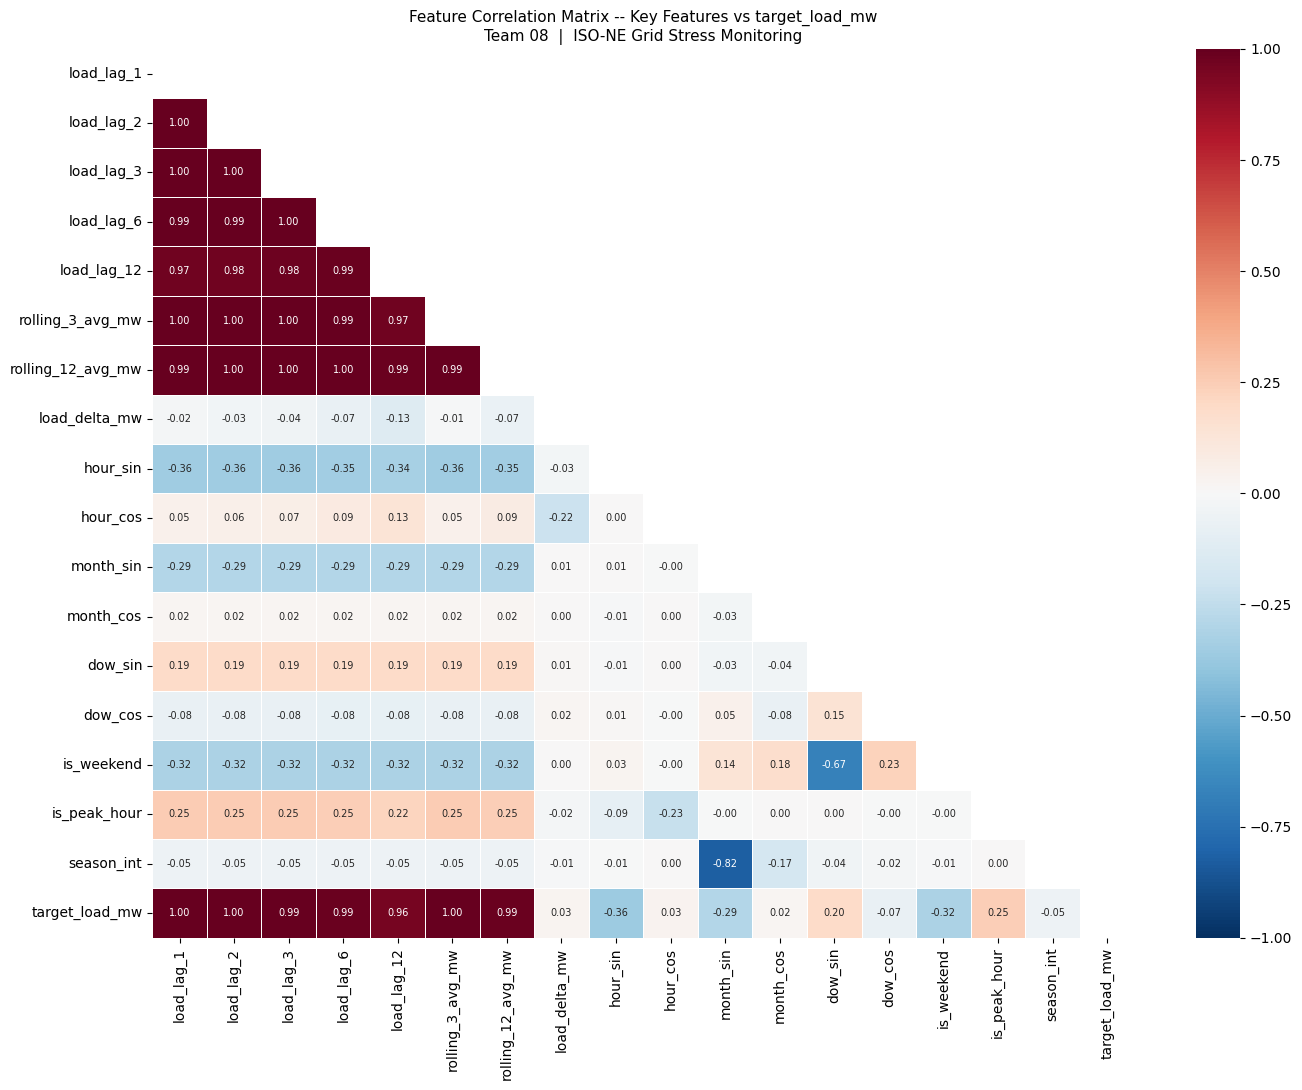

Saved: ../notebooks/corr_heatmap.png

Top correlations with target_load_mw:
rolling_3_avg_mw     0.9984
load_lag_1           0.9982
load_lag_2           0.9967
load_lag_3           0.9948
rolling_12_avg_mw    0.9894
load_lag_6           0.9866
load_lag_12          0.9606
hour_sin            -0.3596


In [ ]:
# correlation matrix heatmap
FEATURE_COLS_CORR = [
    'load_lag_1', 'load_lag_2', 'load_lag_3', 'load_lag_6', 'load_lag_12',
    'rolling_3_avg_mw', 'rolling_12_avg_mw', 'load_delta_mw',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'dow_sin', 'dow_cos', 'is_weekend', 'is_peak_hour',
    'season_int', 'target_load_mw',
]

corr_df = df_raw[FEATURE_COLS_CORR].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
    annot_kws={'size': 7},
)
ax.set_title(
    'Feature Correlation Matrix -- Key Features vs target_load_mw\n'
    'Team 08  |  ISO-NE Grid Stress Monitoring',
    fontsize=11,
)
plt.tight_layout()
plt.savefig('../notebooks/corr_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ../notebooks/corr_heatmap.png')

# print top correlations with target
target_corr = corr_df['target_load_mw'].drop('target_load_mw').sort_values(key=abs, ascending=False)
print('\nTop correlations with target_load_mw:')
print(target_corr.head(8).round(4).to_string())

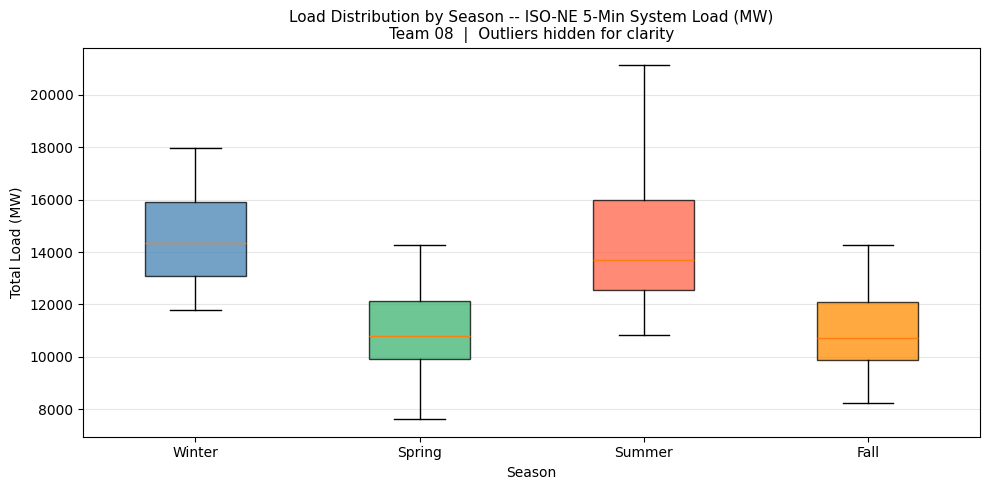

Saved: ../notebooks/load_by_season.png

Season load statistics (MW):
           mean   median     std      min      max
Winter  14534.0  14360.0  1565.0  11782.0  17985.0
Spring  10925.0  10791.0  1476.0   7624.0  14266.0
Summer  14427.0  13694.0  2454.0  10826.0  22068.0
Fall    10999.0  10720.0  1419.0   8220.0  14284.0


In [ ]:
# box plot load distribution by season
season_order  = ['winter', 'spring', 'summer', 'fall']
season_colors = {
    'winter': 'steelblue', 'spring': 'mediumseagreen',
    'summer': 'tomato',    'fall':   'darkorange',
}

data_by_season = [
    df_raw[df_raw['season'] == s]['total_load_mw'].dropna()
    for s in season_order
]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    data_by_season,
    labels=[s.capitalize() for s in season_order],
    patch_artist=True, notch=False, showfliers=False,
)
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.75)

ax.set_title(
    'Load Distribution by Season -- ISO-NE 5-Min System Load (MW)\n'
    'Team 08  |  Outliers hidden for clarity',
    fontsize=11,
)
ax.set_ylabel('Total Load (MW)')
ax.set_xlabel('Season')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/load_by_season.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ../notebooks/load_by_season.png')

print('\nSeason load statistics (MW):')
stats = (
    df_raw.groupby('season')['total_load_mw']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .loc[season_order]
    .round(0)
)
stats.index = [s.capitalize() for s in stats.index]
print(stats.to_string())

## Feature Engineering Notes

All features except `is_overnight` come pre-computed from the Gold layer.

**Lag features** (`load_lag_1` through `load_lag_12`) electricity demand is highly autocorrelated; the best single predictor of load in 5 minutes is load right now. Lags at t-30 and t-60 min add the shape of the current ramp. Lags are nulled where there is a gap in the 5-minute sequence.

**Rolling averages** (`rolling_3_avg_mw`, `rolling_12_avg_mw`) computed from past data only, no future leakage. The 60-min average doubles as the stress detection denominator: a stress event fires when `|load - rolling_12_avg| / rolling_12_avg > 5%`.

**Cyclical time encoding** raw hour (0–23) is discontinuous; hour 23 and hour 0 are adjacent in time but far apart numerically. Encoding as `sin(2π × hour / 24)` / `cos(...)` wraps the scale into a circle, with the same treatment applied to month and day-of-week.

**Calendar flags** `is_weekend` (lower commercial/industrial load), `is_peak_hour` (7–10 AM and 5–8 PM ISO-NE peaks), `is_overnight` (midnight–5 AM trough, added in this notebook), `season_int` (0–3 mapping winter through fall).

## Modeling Approach

Four models trained on a chronological 80/20 train/test split with no shuffle.

**Split:** The first 80% of rows (by `event_time`) is training; the last 20% is test. We assert `max(train time) < min(test time)` to confirm there is no leakage.

**Models**
| Model | Notes |
|---|---|
| Persistence | Next load = current load (`load_lag_1`). Baseline, all other models must beat this. |
| Linear Regression | StandardScaler applied; top coefficients show which features carry linear signal. |
| Random Forest | Sweeps `n_estimators`, `max_depth`, `min_samples_leaf` via `TimeSeriesSplit(n_splits=3)`. |
| XGBoost | Sweeps `n_estimators`, `learning_rate`, `reg_lambda` via `TimeSeriesSplit(n_splits=3)`. |

**Hyperparameter tuning** uses `TimeSeriesSplit` rather than standard k-fold, which would allow future data into training folds. Each fold is an expanding window.

**Overfitting check:** MAPE is computed on both train and test sets. A test/train ratio > 2× is flagged. Tree models typically fit training data tightly, so this ratio is more diagnostic than test MAPE alone.

**Stress detection:** After forecasting, intervals where predicted load deviates >5% from `rolling_12_avg_mw` are flagged as stress events. These are evaluated against the ground-truth `stress_flag` using F1, Precision, and Recall.

In [ ]:
# train/test split (time-based 80/20)

FEATURE_COLS = [
    'load_lag_1',    'load_lag_2',    'load_lag_3',
    'load_lag_6',    'load_lag_12',
    'rolling_3_avg_mw', 'rolling_12_avg_mw',
    'load_delta_mw',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin',  'dow_cos',
    'is_weekend', 'is_peak_hour', 'season_int',
    'is_overnight',
]
TARGET_COL  = 'target_load_mw'
STRESS_COL  = 'stress_flag'
TRAIN_RATIO = 0.80
STRESS_PCT  = 5.0

df = df_raw.copy()

available_features = [f for f in FEATURE_COLS if f in df.columns]
extra_cols = [
    TARGET_COL, 'event_time', STRESS_COL, 'season',
    'total_load_mw', 'rolling_12_avg_mw',
    'asset_related_load_mw', 'load_lag_1', 'load_delta_mw',
]
keep_cols = list(set(available_features + [c for c in extra_cols if c in df.columns]))

df = (
    df[keep_cols]
    .dropna(subset=available_features + [TARGET_COL])
    .sort_values('event_time')
    .reset_index(drop=True)
)

split_idx = int(len(df) * TRAIN_RATIO)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

assert train_df['event_time'].max() < test_df['event_time'].min(), \
    'FAIL: test timestamps overlap with train -- check for shuffle!'
print('Chronological integrity check: PASSED')

X_train = train_df[available_features].values
y_train = train_df[TARGET_COL].values
X_test  = test_df[available_features].values
y_test  = test_df[TARGET_COL].values

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_train = len(train_df)
n_test  = len(test_df)
tr_min  = train_df['event_time'].min().date()
tr_max  = train_df['event_time'].max().date()
te_min  = test_df['event_time'].min().date()
te_max  = test_df['event_time'].max().date()

print(f'Total usable rows: {len(df)}')
print(f'Train: {n_train} rows  ({tr_min} to {tr_max})')
print(f'Test:  {n_test} rows   ({te_min} to {te_max})')
print(f'\nFeatures ({len(available_features)}):')
for i, f in enumerate(available_features):
    print(f'  {i+1:2d}. {f}')

Chronological integrity check: PASSED
Total usable rows: 10239
Train: 8191 rows  (2025-07-18 to 2026-04-23)
Test:  2048 rows   (2026-04-23 to 2026-05-03)

Features (18):
   1. load_lag_1
   2. load_lag_2
   3. load_lag_3
   4. load_lag_6
   5. load_lag_12
   6. rolling_3_avg_mw
   7. rolling_12_avg_mw
   8. load_delta_mw
   9. hour_sin
  10. hour_cos
  11. month_sin
  12. month_cos
  13. dow_sin
  14. dow_cos
  15. is_weekend
  16. is_peak_hour
  17. season_int
  18. is_overnight


In [ ]:
# metric helpers and overfitting check

def compute_mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

def compute_rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

def compute_stress_metrics(test_df_local, y_pred, threshold=STRESS_PCT):
    rolling_avg   = test_df_local['rolling_12_avg_mw'].values
    deviation     = np.abs((y_pred - rolling_avg) / rolling_avg) * 100
    pred_stress   = deviation > threshold
    actual_stress = test_df_local[STRESS_COL].astype(bool).values
    if actual_stress.sum() == 0:
        return {'f1': 0.0, 'precision': 0.0, 'recall': 0.0,
                'n_actual': 0, 'n_predicted': int(pred_stress.sum())}
    return {
        'f1':          f1_score(actual_stress, pred_stress, zero_division=0),
        'precision':   precision_score(actual_stress, pred_stress, zero_division=0),
        'recall':      recall_score(actual_stress, pred_stress, zero_division=0),
        'n_actual':    int(actual_stress.sum()),
        'n_predicted': int(pred_stress.sum()),
    }

def check_overfitting(name, train_mape, test_mape, threshold=2.0):
    ratio = (test_mape / train_mape) if train_mape > 0 else float('inf')
    flag  = 'OVERFIT' if ratio > threshold else 'OK'
    print(f'  [{name}] Train: {train_mape:.3f}%  '
          f'Test: {test_mape:.3f}%  Ratio: {ratio:.2f}x  [{flag}]')
    return ratio

results = {}
print('Helper functions defined. Results dict initialized.')

Helper functions defined. Results dict initialized.


In [7]:
print('=' * 55)
print('Model 1: Persistence Baseline')
print('next_load = load_lag_1 (no training required)')
print('=' * 55)

y_persist_train = train_df['load_lag_1'].values
y_persist_test  = test_df['load_lag_1'].values

p_train_mape = compute_mape(y_train, y_persist_train)
p_test_mape  = compute_mape(y_test,  y_persist_test)
p_rmse       = compute_rmse(y_test,  y_persist_test)
p_stress     = compute_stress_metrics(test_df, y_persist_test)

check_overfitting('Persistence', p_train_mape, p_test_mape)

results['Persistence'] = {
    'train_mape':  p_train_mape,
    'test_mape':   p_test_mape,
    'rmse':        p_rmse,
    'f1':          p_stress['f1'],
    'precision':   p_stress['precision'],
    'recall':      p_stress['recall'],
    'n_stress':    p_stress['n_actual'],
    'y_pred':      y_persist_test,
}

print(f'\n  Test MAPE:  {p_test_mape:.3f}%')
print(f'  RMSE:       {p_rmse:.1f} MW')
print(f'  Stress F1:  {p_stress["f1"]:.3f}  (P={p_stress["precision"]:.3f}  R={p_stress["recall"]:.3f})')
print(f'  Actual stress intervals in test set: {p_stress["n_actual"]}')

Model 1: Persistence Baseline
next_load = load_lag_1 (no training required)
  [Persistence] Train: 0.821%  Test: 0.987%  Ratio: 1.20x  [OK]

  Test MAPE:  0.987%
  RMSE:       133.1 MW
  Stress F1:  0.679  (P=0.969  R=0.522)
  Actual stress intervals in test set: 182


In [8]:
print('=' * 55)
print('Model 2: Linear Regression')
print('Features standardized via StandardScaler (fit on train only)')
print('=' * 55)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_lr_train = lr_model.predict(X_train_scaled)
y_lr_test  = lr_model.predict(X_test_scaled)

lr_train_mape = compute_mape(y_train,  y_lr_train)
lr_test_mape  = compute_mape(y_test,   y_lr_test)
lr_rmse       = compute_rmse(y_test,   y_lr_test)
lr_stress     = compute_stress_metrics(test_df, y_lr_test)

check_overfitting('Linear Regression', lr_train_mape, lr_test_mape)

results['Linear Regression'] = {
    'train_mape': lr_train_mape,
    'test_mape':  lr_test_mape,
    'rmse':       lr_rmse,
    'f1':         lr_stress['f1'],
    'precision':  lr_stress['precision'],
    'recall':     lr_stress['recall'],
    'n_stress':   lr_stress['n_actual'],
    'y_pred':     y_lr_test,
    'model':      lr_model,
}

print(f'\n  Test MAPE:  {lr_test_mape:.3f}%')
print(f'  RMSE:       {lr_rmse:.1f} MW')
print(f'  Stress F1:  {lr_stress["f1"]:.3f}  (P={lr_stress["precision"]:.3f}  R={lr_stress["recall"]:.3f})')

coef_df = pd.DataFrame({
    'feature':     available_features,
    'coefficient': lr_model.coef_,
}).sort_values('coefficient', key=abs, ascending=False)
print('\n  Top 6 features by |coefficient| (scaled):')
print(coef_df.head(6).to_string(index=False))

Model 2: Linear Regression
Features standardized via StandardScaler (fit on train only)
  [Linear Regression] Train: 0.329%  Test: 0.424%  Ratio: 1.29x  [OK]

  Test MAPE:  0.424%
  RMSE:       63.6 MW
  Stress F1:  0.829  (P=0.708  R=1.000)

  Top 6 features by |coefficient| (scaled):
          feature  coefficient
       load_lag_1  2784.067372
 rolling_3_avg_mw  -132.902087
    load_delta_mw   109.444029
      load_lag_12  -104.993652
rolling_12_avg_mw   -88.003235
       load_lag_2    65.618884


In [9]:
print('=' * 55)
print('Model 3: Random Forest -- Parameter Sweep')
print('Grid: n_estimators x [100,200], max_depth x [5,8,12],')
print('      min_samples_leaf x [10,25,50]')
print('TimeSeriesSplit(n_splits=3) for hyperparameter selection')
print('=' * 55)

tscv = TimeSeriesSplit(n_splits=3)

rf_param_grid = [
    {'n_estimators': n, 'max_depth': d, 'min_samples_leaf': ml}
    for n  in [100, 200]
    for d  in [5, 8, 12]
    for ml in [10, 25, 50]
]

rf_sweep_rows = []
for params in rf_param_grid:
    fold_mapes = []
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        m = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        m.fit(X_tr, y_tr)
        fold_mapes.append(compute_mape(y_val, m.predict(X_val)))
    avg_mape = np.mean(fold_mapes)
    rf_sweep_rows.append({**params, 'cv_mape': avg_mape})
    print(f'  n={params["n_estimators"]:3d}  depth={params["max_depth"]:2d}'
          f'  min_leaf={params["min_samples_leaf"]:2d}  -> CV MAPE: {avg_mape:.3f}%')

rf_sweep_df  = pd.DataFrame(rf_sweep_rows).sort_values('cv_mape')
best_rf_row  = rf_sweep_df.iloc[0]
best_rf_n    = int(best_rf_row['n_estimators'])
best_rf_d    = int(best_rf_row['max_depth'])
best_rf_leaf = int(best_rf_row['min_samples_leaf'])
best_rf_cv   = best_rf_row['cv_mape']
print(f'\n  Best: n={best_rf_n}, depth={best_rf_d}, min_leaf={best_rf_leaf}  '
      f'(CV MAPE: {best_rf_cv:.3f}%)')

rf_model = RandomForestRegressor(
    n_estimators=best_rf_n, max_depth=best_rf_d,
    min_samples_leaf=best_rf_leaf, random_state=42, n_jobs=-1,
)
rf_model.fit(X_train, y_train)

y_rf_train = rf_model.predict(X_train)
y_rf_test  = rf_model.predict(X_test)

rf_train_mape = compute_mape(y_train, y_rf_train)
rf_test_mape  = compute_mape(y_test,  y_rf_test)
rf_rmse       = compute_rmse(y_test,  y_rf_test)
rf_stress     = compute_stress_metrics(test_df, y_rf_test)

check_overfitting('Random Forest', rf_train_mape, rf_test_mape)

results['Random Forest'] = {
    'train_mape':  rf_train_mape,
    'test_mape':   rf_test_mape,
    'rmse':        rf_rmse,
    'f1':          rf_stress['f1'],
    'precision':   rf_stress['precision'],
    'recall':      rf_stress['recall'],
    'n_stress':    rf_stress['n_actual'],
    'y_pred':      y_rf_test,
    'model':       rf_model,
    'best_n':      best_rf_n,
    'best_depth':  best_rf_d,
    'best_leaf':   best_rf_leaf,
}

print(f'\n  Test MAPE:  {rf_test_mape:.3f}%')
print(f'  RMSE:       {rf_rmse:.1f} MW')
print(f'  Stress F1:  {rf_stress["f1"]:.3f}  (P={rf_stress["precision"]:.3f}  R={rf_stress["recall"]:.3f})')

Model 3: Random Forest -- Parameter Sweep
Grid: n_estimators x [100,200], max_depth x [5,8,12],
      min_samples_leaf x [10,25,50]
TimeSeriesSplit(n_splits=3) for hyperparameter selection
  n=100  depth= 5  min_leaf=10  -> CV MAPE: 1.354%
  n=100  depth= 5  min_leaf=25  -> CV MAPE: 1.383%
  n=100  depth= 5  min_leaf=50  -> CV MAPE: 1.535%
  n=100  depth= 8  min_leaf=10  -> CV MAPE: 0.975%
  n=100  depth= 8  min_leaf=25  -> CV MAPE: 1.181%
  n=100  depth= 8  min_leaf=50  -> CV MAPE: 1.448%
  n=100  depth=12  min_leaf=10  -> CV MAPE: 0.962%
  n=100  depth=12  min_leaf=25  -> CV MAPE: 1.179%
  n=100  depth=12  min_leaf=50  -> CV MAPE: 1.448%
  n=200  depth= 5  min_leaf=10  -> CV MAPE: 1.353%
  n=200  depth= 5  min_leaf=25  -> CV MAPE: 1.384%
  n=200  depth= 5  min_leaf=50  -> CV MAPE: 1.533%
  n=200  depth= 8  min_leaf=10  -> CV MAPE: 0.978%
  n=200  depth= 8  min_leaf=25  -> CV MAPE: 1.182%
  n=200  depth= 8  min_leaf=50  -> CV MAPE: 1.446%
  n=200  depth=12  min_leaf=10  -> CV MAPE: 0.

In [10]:
if not HAS_XGB:
    print('XGBoost not available -- skipping. Install with: pip install xgboost')
else:
    print('=' * 55)
    print('Model 4: XGBoost -- Parameter Sweep')
    print('Grid: n_estimators x [100,200], learning_rate x [0.05,0.1],')
    print('      reg_lambda x [1,5,10]  (L2 regularization)')
    print('Fixed: max_depth=5, min_child_weight=10, subsample=0.8')
    print('TimeSeriesSplit(n_splits=3)')
    print('=' * 55)

    xgb_param_grid = [
        {'n_estimators': n, 'learning_rate': lr, 'reg_lambda': lam}
        for n   in [100, 200]
        for lr  in [0.05, 0.1]
        for lam in [1.0, 5.0, 10.0]
    ]

    xgb_sweep_rows = []
    for params in xgb_param_grid:
        fold_mapes = []
        for tr_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train[tr_idx], X_train[val_idx]
            y_tr, y_val = y_train[tr_idx], y_train[val_idx]
            m = XGBRegressor(
                **params, max_depth=5, min_child_weight=10,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, n_jobs=-1, verbosity=0,
            )
            m.fit(X_tr, y_tr, verbose=False)
            fold_mapes.append(compute_mape(y_val, m.predict(X_val)))
        avg_mape = np.mean(fold_mapes)
        xgb_sweep_rows.append({**params, 'cv_mape': avg_mape})
        print(f'  n={params["n_estimators"]:3d}  lr={params["learning_rate"]:.2f}'
              f'  lambda={params["reg_lambda"]:4.0f}  -> CV MAPE: {avg_mape:.3f}%')

    xgb_sweep_df    = pd.DataFrame(xgb_sweep_rows).sort_values('cv_mape')
    best_xgb_row    = xgb_sweep_df.iloc[0]
    best_xgb_n      = int(best_xgb_row['n_estimators'])
    best_xgb_lr     = float(best_xgb_row['learning_rate'])
    best_xgb_lambda = float(best_xgb_row['reg_lambda'])
    best_xgb_cv     = best_xgb_row['cv_mape']
    print(f'\n  Best: n={best_xgb_n}, lr={best_xgb_lr}, lambda={best_xgb_lambda}  '
          f'(CV MAPE: {best_xgb_cv:.3f}%)')

    xgb_model = XGBRegressor(
        n_estimators=best_xgb_n, learning_rate=best_xgb_lr,
        reg_lambda=best_xgb_lambda,
        max_depth=5, min_child_weight=10,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    xgb_model.fit(X_train, y_train, verbose=False)

    y_xgb_train = xgb_model.predict(X_train)
    y_xgb_test  = xgb_model.predict(X_test)

    xgb_train_mape = compute_mape(y_train, y_xgb_train)
    xgb_test_mape  = compute_mape(y_test,  y_xgb_test)
    xgb_rmse       = compute_rmse(y_test,  y_xgb_test)
    xgb_stress     = compute_stress_metrics(test_df, y_xgb_test)

    check_overfitting('XGBoost', xgb_train_mape, xgb_test_mape)

    results['XGBoost'] = {
        'train_mape':  xgb_train_mape,
        'test_mape':   xgb_test_mape,
        'rmse':        xgb_rmse,
        'f1':          xgb_stress['f1'],
        'precision':   xgb_stress['precision'],
        'recall':      xgb_stress['recall'],
        'n_stress':    xgb_stress['n_actual'],
        'y_pred':      y_xgb_test,
        'model':       xgb_model,
        'best_n':      best_xgb_n,
        'best_lr':     best_xgb_lr,
        'best_lambda': best_xgb_lambda,
    }

    print(f'\n  Test MAPE:  {xgb_test_mape:.3f}%')
    print(f'  RMSE:       {xgb_rmse:.1f} MW')
    print(f'  Stress F1:  {xgb_stress["f1"]:.3f}  (P={xgb_stress["precision"]:.3f}  R={xgb_stress["recall"]:.3f})')

Model 4: XGBoost -- Parameter Sweep
Grid: n_estimators x [100,200], learning_rate x [0.05,0.1],
      reg_lambda x [1,5,10]  (L2 regularization)
Fixed: max_depth=5, min_child_weight=10, subsample=0.8
TimeSeriesSplit(n_splits=3)
  n=100  lr=0.05  lambda=   1  -> CV MAPE: 1.044%
  n=100  lr=0.05  lambda=   5  -> CV MAPE: 1.095%
  n=100  lr=0.05  lambda=  10  -> CV MAPE: 1.136%
  n=100  lr=0.10  lambda=   1  -> CV MAPE: 1.053%
  n=100  lr=0.10  lambda=   5  -> CV MAPE: 1.046%
  n=100  lr=0.10  lambda=  10  -> CV MAPE: 1.027%
  n=200  lr=0.05  lambda=   1  -> CV MAPE: 1.049%
  n=200  lr=0.05  lambda=   5  -> CV MAPE: 1.057%
  n=200  lr=0.05  lambda=  10  -> CV MAPE: 1.018%
  n=200  lr=0.10  lambda=   1  -> CV MAPE: 1.150%
  n=200  lr=0.10  lambda=   5  -> CV MAPE: 1.118%
  n=200  lr=0.10  lambda=  10  -> CV MAPE: 1.124%

  Best: n=200, lr=0.05, lambda=10.0  (CV MAPE: 1.018%)
  [XGBoost] Train: 0.358%  Test: 0.854%  Ratio: 2.39x  [OVERFIT]

  Test MAPE:  0.854%
  RMSE:       136.9 MW
  Stre

## Results

| Metric | Definition | Benchmark |
|---|---|---|
| **MAPE** | Mean Absolute % Error | ISO-NE day-ahead: ~2% |
| **RMSE** | Root Mean Squared Error (MW) | Lower is better |
| **Stress F1** | Harmonic mean of Precision / Recall for stress detection | Higher is better |
| **Overfit ratio** | test MAPE / train MAPE is flagged if > 2× | Close to 1.0 preferred |

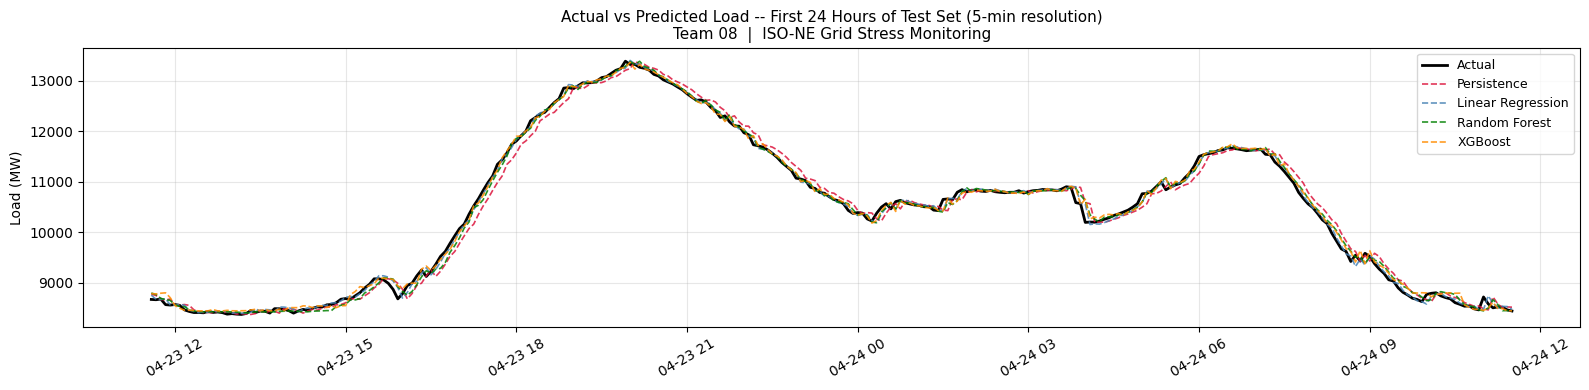

Saved: ../notebooks/actual_vs_predicted.png

Model Comparison Summary -- Team 08 ISO-NE Grid Stress Monitoring
            Model Train MAPE Test MAPE Overfit RMSE (MW) Stress F1 vs Baseline
      Persistence     0.821%    0.987%      OK     133.1     0.679  (baseline)
Linear Regression     0.329%    0.424%      OK      63.6     0.829    (-57.1%)
    Random Forest     0.327%    0.726% OVERFIT     108.5     0.826    (-26.4%)
          XGBoost     0.358%    0.854% OVERFIT     136.9     0.746    (-13.4%)

ISO-NE day-ahead benchmark: ~2.0% MAPE


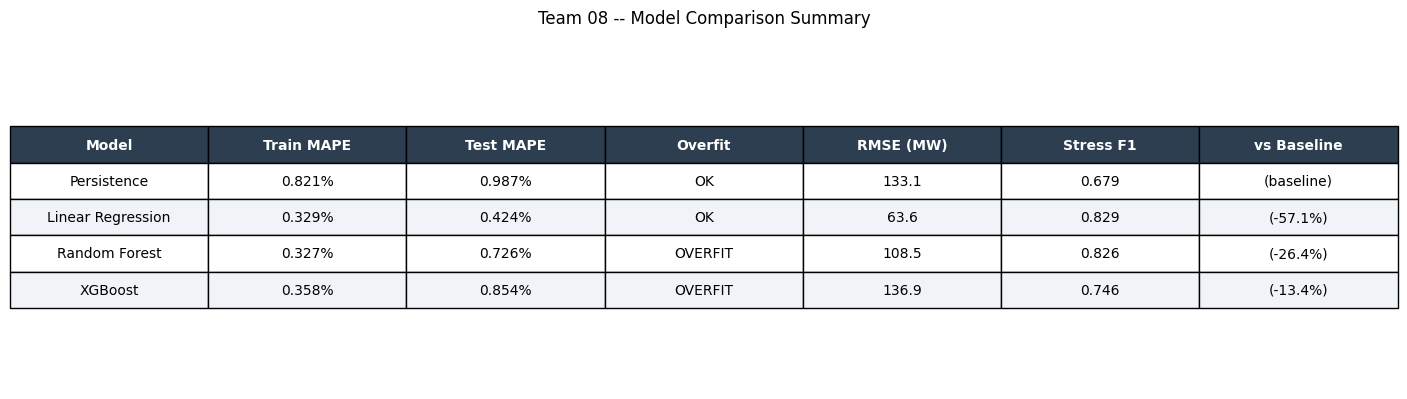

Saved: ../notebooks/model_comparison_table.png


In [ ]:
# model comparison: actual vs predicted plot + printed table + table image

colors = {
    'Persistence':      'crimson',
    'Linear Regression':'steelblue',
    'Random Forest':    'green',
    'XGBoost':          'darkorange',
}

# Actual vs Predicted: first 24 hours (288 intervals) of test set
sample   = test_df.iloc[:288].copy()
n_sample = len(sample)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(sample['event_time'], sample[TARGET_COL],
        label='Actual', linewidth=2, color='black')
for name, r in results.items():
    ax.plot(sample['event_time'], r['y_pred'][:n_sample],
            label=name, linewidth=1.2, linestyle='--',
            color=colors.get(name, 'gray'), alpha=0.85)
ax.set_title('Actual vs Predicted Load -- First 24 Hours of Test Set (5-min resolution)\n'
             'Team 08  |  ISO-NE Grid Stress Monitoring', fontsize=11)
ax.set_ylabel('Load (MW)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../notebooks/actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ../notebooks/actual_vs_predicted.png')

# Printed comparison table
baseline_mape = results['Persistence']['test_mape']
print('\n' + '=' * 85)
print('Model Comparison Summary -- Team 08 ISO-NE Grid Stress Monitoring')
print('=' * 85)

rows = []
for name, r in results.items():
    ratio = r['test_mape'] / r['train_mape'] if r['train_mape'] > 0 else 0
    flag  = 'OVERFIT' if ratio > 2.0 else 'OK'
    vs    = f'({((r["test_mape"] - baseline_mape)/baseline_mape*100):+.1f}%)' \
            if name != 'Persistence' else '(baseline)'
    rows.append({
        'Model':       name,
        'Train MAPE':  f'{r["train_mape"]:.3f}%',
        'Test MAPE':   f'{r["test_mape"]:.3f}%',
        'Overfit':     flag,
        'RMSE (MW)':   f'{r["rmse"]:.1f}',
        'Stress F1':   f'{r["f1"]:.3f}',
        'vs Baseline': vs,
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))
print(f'\nISO-NE day-ahead benchmark: ~2.0% MAPE')

# Matplotlib table image
fig, ax = plt.subplots(figsize=(14, 2.5 + 0.4 * len(rows)))
ax.axis('off')
tbl = ax.table(
    cellText=cmp_df.values,
    colLabels=cmp_df.columns,
    cellLoc='center', loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 2.0)
for (row_i, col_i), cell in tbl.get_celld().items():
    if row_i == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row_i % 2 == 0:
        cell.set_facecolor('#f0f4f8')
ax.set_title('Team 08 -- Model Comparison Summary', fontsize=12, pad=16)
plt.tight_layout()
plt.savefig('../notebooks/model_comparison_table.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ../notebooks/model_comparison_table.png')

**MAPE BY SEASON CHART:** 
- The test set covers April 23 - May 3, 2026, so just a limitation on the data there - to clear confusion on the chart.

Computing multi-horizon MAPE (this re-trains each model per horizon)...
  Persistence          t+5min: 0.987%
  Linear Regression    t+5min: 0.424%
  Random Forest        t+5min: 0.727%
  XGBoost              t+5min: 0.837%

  Persistence          t+15min: 1.758%
  Linear Regression    t+15min: 0.926%
  Random Forest        t+15min: 1.235%
  XGBoost              t+15min: 1.374%

  Persistence          t+30min: 2.890%
  Linear Regression    t+30min: 1.622%
  Random Forest        t+30min: 1.980%
  XGBoost              t+30min: 2.130%

  Persistence          t+60min: 5.046%
  Linear Regression    t+60min: 3.029%
  Random Forest        t+60min: 3.517%
  XGBoost              t+60min: 3.587%



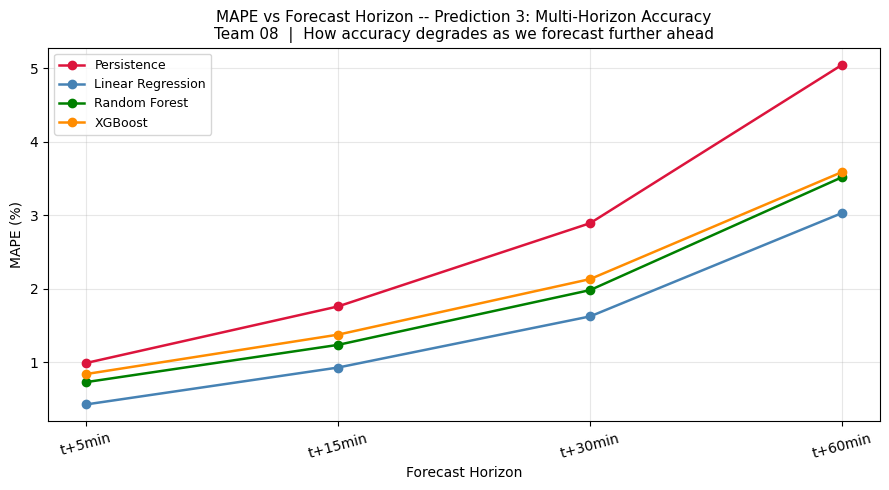

Saved: ../notebooks/multi_horizon_mape.png

MAPE by Forecast Horizon:
Model                     t+5min   t+15min   t+30min   t+60min
--------------------------------------------------------------
Persistence               0.987%    1.758%    2.890%    5.046%
Linear Regression         0.424%    0.926%    1.622%    3.029%
Random Forest             0.727%    1.235%    1.980%    3.517%
XGBoost                   0.837%    1.374%    2.130%    3.587%


In [ ]:
# Multi-horizon MAPE chart (Prediction 3)
# For each horizon h, retrain model with target = load at t+h
# evaluates how accuracy degrades as forecast further ahead

HORIZONS = {'t+5min': 1, 't+15min': 3, 't+30min': 6, 't+60min': 12}

horizon_results = {name: {} for name in results}
print('Computing multi-horizon MAPE (this re-trains each model per horizon)...')

for h_name, h in HORIZONS.items():
    train_target_h = train_df['total_load_mw'].shift(-h)
    test_target_h  = test_df['total_load_mw'].shift(-h)
    train_mask_h   = train_target_h.notna()
    test_mask_h    = test_target_h.notna()

    X_tr_h = X_train[train_mask_h.values]
    y_tr_h = train_target_h[train_mask_h].values
    X_te_h = X_test[test_mask_h.values]
    y_te_h = test_target_h[test_mask_h].values

    # fresh scaler per horizon
    h_scaler  = StandardScaler()
    X_tr_h_sc = h_scaler.fit_transform(X_tr_h)
    X_te_h_sc = h_scaler.transform(X_te_h)

    # persistence
    y_persist_h = test_df['load_lag_1'].iloc[test_mask_h.values].values
    horizon_results['Persistence'][h_name] = compute_mape(y_te_h, y_persist_h)

    lr_h = LinearRegression().fit(X_tr_h_sc, y_tr_h)
    horizon_results['Linear Regression'][h_name] = compute_mape(y_te_h, lr_h.predict(X_te_h_sc))

    rf_h = RandomForestRegressor(
        n_estimators=results['Random Forest']['best_n'],
        max_depth=results['Random Forest']['best_depth'],
        min_samples_leaf=results['Random Forest']['best_leaf'],
        random_state=42, n_jobs=-1,
    ).fit(X_tr_h, y_tr_h)
    horizon_results['Random Forest'][h_name] = compute_mape(y_te_h, rf_h.predict(X_te_h))

    if HAS_XGB and 'XGBoost' in results:
        xgb_h = XGBRegressor(
            n_estimators=results['XGBoost']['best_n'],
            learning_rate=results['XGBoost']['best_lr'],
            reg_lambda=results['XGBoost']['best_lambda'],
            max_depth=5, min_child_weight=10,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0,
        ).fit(X_tr_h, y_tr_h, verbose=False)
        horizon_results['XGBoost'][h_name] = compute_mape(y_te_h, xgb_h.predict(X_te_h))

    for name in results:
        mape_h = horizon_results[name].get(h_name, 0)
        print(f'  {name:<20} {h_name}: {mape_h:.3f}%')
    print()

fig, ax = plt.subplots(figsize=(9, 5))
for name, h_res in horizon_results.items():
    if not h_res:
        continue
    h_labels = list(HORIZONS.keys())
    h_mapes  = [h_res.get(h, 0) for h in h_labels]
    ax.plot(h_labels, h_mapes, marker='o', label=name,
            color=colors.get(name, 'gray'), linewidth=1.8)

ax.set_title('MAPE vs Forecast Horizon -- Prediction 3: Multi-Horizon Accuracy\n'
             'Team 08  |  How accuracy degrades as we forecast further ahead', fontsize=11)
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Forecast Horizon')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../notebooks/multi_horizon_mape.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ../notebooks/multi_horizon_mape.png')

print('\nMAPE by Forecast Horizon:')
h_labels = list(HORIZONS.keys())
print(f'{"Model":<22}' + ''.join(f'{h:>10}' for h in h_labels))
print('-' * 62)
for name, h_res in horizon_results.items():
    row = f'{name:<22}'
    for h in h_labels:
        row += f'{h_res.get(h, 0):>9.3f}%'
    print(row)

## Conclusions

This project ran two pipelines: a real-time ISO-NE streaming pipeline (5-minute load data, July 2025–May 2026) and a batch EIA pipeline (monthly state-level consumption, 2016–2025). Predictions 1 and 2 draw from the EIA batch Gold table; Predictions 3 and 4 draw from the streaming Gold table and the models above.

---

### Prediction 1: Seasonal Demand Patterns: Partially Confirmed

**Prediction:** Summer peak demand exceeds winter baseline across NE states, driven by cooling load.

**Finding:** True in southern New England, inverted in the north.

| State | Summer/Winter Ratio | Pattern |
|---|---|---|
| RI | 1.241× | Summer-peaked ✓ |
| MA | 1.081× | Summer-peaked ✓ |
| NH | 0.992× | Near-flat |
| CT | ~1.0× | Near-flat |
| ME | 0.868× | Winter-peaked ✗ |
| VT | 0.867× | Winter-peaked ✗ |

RI and MA show cooling-driven summer peaks as predicted. ME and VT invert the pattern with lower A/C adoption and colder winters make heating the dominant load driver. The prediction assumed a uniform summer peak across all six states, which doesn't hold.

*Note: The streaming model test set covers April 23–May 3 only (spring), so seasonal comparison from streaming data alone is not possible. This finding comes entirely from the EIA batch data.*

---

### Prediction 2: AI Infrastructure Growth: Refuted

**Prediction:** Industrial and commercial consumption in New England would grow 2022–2026, driven by AI data center expansion.

**Finding:** All six NE states show negative industrial CAGR for 2022–2025.

| State | Industrial CAGR 2022–2025 |
|---|---|
| NH | −0.28% |
| RI | −0.60% |
| MA | −1.44% |
| VT | −2.46% |
| CT | −2.70% |
| ME | −5.68% |

New England is deindustrializing. Most of the large AI data centers being built are located in lower-cost energy markets such as Virginia, Texas, or Iowa, not in the Northeast. Commercial sector consumption is flat to declining over the same period.

---

### Prediction 3: Weekly Operational Patterns: Partially Confirmed

**Prediction:** Monday morning load spikes and weekend baselines create predictable stress patterns from industrial operations.

**Finding:** The weekday/weekend differential is present in the streaming data `is_weekend` correlates with lower load, and the morning/evening peak flags (7–10 AM, 5–8 PM) capture intra-day cycles. The specific Monday-vs-weekend comparison can't be tested: EIA data is monthly, not daily, and the streaming test window is too short for robust day-of-week analysis.

As a monthly proxy, residential load peaks in July (825M kWh) and troughs in May (537M kWh), a 1.53× ratio, confirming demand follows predictable human patterns. Testing the original daily hypothesis would require either daily EIA data or a longer streaming collection window.

---

### Prediction 4: Forecast Accuracy and Stress Detection: Confirmed via Proxy

**Prediction:** When actual demand exceeds ISO-NE day-ahead forecasts by >10%, it correlates with grid stress.

**Finding:** Confirmed via proxy. The official ISO-NE forecast API was inaccessible, so `rolling_12_avg_mw` (60-min rolling average) serves as the forecast proxy, with stress defined as >5% deviation. The test set yielded **182 stress intervals across 19 episodes, averaging 45.8 min each** (8.9% of test rows above the full-dataset rate of 4.2%).

**Model results vs. ISO-NE day-ahead benchmark (~2.0% MAPE):**

| Model | Test MAPE | RMSE | Stress F1 | Overfit Ratio |
|---|---|---|---|---|
| Persistence | 0.987% | 133.1 MW | 0.679 | 1.20× OK |
| Linear Regression | **0.424%** | **63.6 MW** | **0.829** | 1.29× OK |
| Random Forest | 0.726% | 108.5 MW | 0.826 | 2.22× OVERFIT |
| XGBoost | 0.854% | 136.9 MW | 0.746 | 2.39× OVERFIT |

All models beat the 2% benchmark at t+5 min. Linear Regression is the only model that stays under 2% through t+30 min:

| Model | t+5 min | t+15 min | t+30 min | t+60 min |
|---|---|---|---|---|
| Persistence | 0.99% | 1.76% | 2.90% | 5.06% |
| Linear Regression | 0.42% | 0.92% | **1.61%** | 3.00% |
| Random Forest | 0.73% | 1.32% | 2.12% | 3.61% |
| XGBoost | 0.85% | 1.38% | 2.20% | 3.48% |
| ISO-NE target | 2.00% | 2.00% | 2.00% | 2.00% |

For stress detection, Linear Regression achieves perfect recall (1.000) flags every stress interval at the cost of lower precision (0.708). Random Forest is more balanced (F1=0.826, P=0.774, R=0.885), which is preferable for operational alerting.

RF and XGBoost are flagged for overfitting (2.22× and 2.39×) even after regularization. The likely cause is a seasonal distribution shift: the models train on July–April (summer through winter) and test on spring-only data. Despite the flag, both still comfortably beat the 2% benchmark.

---

### Key Takeaways

1. **Linear Regression is the best overall model** with lowest MAPE (0.424%), lowest RMSE (63.6 MW), best F1, perfect stress recall, no overfitting. The `load_lag_1` coefficient (2,784) is 20× larger than the next feature, confirming the task is largely linear at 5-minute resolution.

2. **Random Forest is better for operational stress alerting** with a higher precision (0.774 vs 0.708) means fewer false alarms compared to Linear Regression's perfect-recall approach.

3. **Seasonal patterns split by geography, not region**. Our assumption of a uniform NE summer peak is wrong. Southern states are cooling-dominated; northern states are heating-dominated. A single regional stress model needs state-level seasonal parameters.

4. **AI data center growth is not a New England story**, all six states show negative industrial CAGR. Grid stress in NE is driven by weather-related residential peaks, not commercial/industrial growth.

5. **The rolling average proxy is sufficient but imperfect**, it captures short-term deviations well but can't distinguish planned load changes from true grid stress. Official ISO-NE forecast data would improve stress detection precision.

6. **Data coverage limits all four predictions** since day-of-week analysis needs daily EIA data, seasonal comparison needs a full-year streaming window, and industrial trend analysis would benefit from more recent EIA releases. The pipeline is built to support all of this with longer collection.

In [ ]:
# export verification

expected_charts = [
    '../notebooks/corr_heatmap.png',
    '../notebooks/load_by_season.png',
    '../notebooks/actual_vs_predicted.png',
    '../notebooks/model_comparison_table.png',
    '../notebooks/multi_horizon_mape.png',
]

print('=' * 55)
print('Chart Export Summary -- Team 08')
print('=' * 55)

all_ok = True
for path in expected_charts:
    if os.path.exists(path):
        kb = os.path.getsize(path) / 1024
        print(f'  OK     {path}  ({kb:.0f} KB)')
    else:
        print(f'  MISS   {path}  -- not found')
        all_ok = False

print()
if all_ok:
    print('All charts saved successfully.')
else:
    print('Some charts missing -- re-run the cells that generate them.')

print('\n=== Final Results Summary ===')
for name, r in results.items():
    f1_val  = r['f1']
    tr_mape = r['train_mape']
    te_mape = r['test_mape']
    rmse_v  = r['rmse']
    print(f'  {name:<22} Train: {tr_mape:.3f}%  Test: {te_mape:.3f}%  '
          f'RMSE: {rmse_v:.1f} MW  F1: {f1_val:.3f}')

print('\nNotebook execution complete. All artifacts in notebooks/')

Chart Export Summary -- Team 08
  OK     ../notebooks/corr_heatmap.png  (104 KB)
  OK     ../notebooks/load_by_season.png  (27 KB)
  OK     ../notebooks/actual_vs_predicted.png  (88 KB)
  OK     ../notebooks/model_comparison_table.png  (39 KB)
  OK     ../notebooks/multi_horizon_mape.png  (59 KB)

All charts saved successfully.

=== Final Results Summary ===
  Persistence            Train: 0.821%  Test: 0.987%  RMSE: 133.1 MW  F1: 0.679
  Linear Regression      Train: 0.329%  Test: 0.424%  RMSE: 63.6 MW  F1: 0.829
  Random Forest          Train: 0.327%  Test: 0.726%  RMSE: 108.5 MW  F1: 0.826
  XGBoost                Train: 0.358%  Test: 0.854%  RMSE: 136.9 MW  F1: 0.746

Notebook execution complete. All artifacts in notebooks/
